In [1]:
from pathlib import Path
import os, sys

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if Path.cwd().resolve() != PROJECT_ROOT:
    os.chdir(PROJECT_ROOT)

root_str = str(PROJECT_ROOT)
if root_str in sys.path:
    sys.path.remove(root_str)
sys.path.insert(0, root_str)

#print("PROJECT_ROOT =", PROJECT_ROOT)
#print("cwd =", Path.cwd())

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="Observation names are not unique. To make them unique, call `.obs_names_make_unique`."
)


In [4]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import torch
import yaml
import scvi
import pickle

In [5]:
control_key = "is_control"
condition_keys = "cytokine"
condition_combined_keys = "condition_combined"
condition_rep_keys = "perturbation_embeddings"
mass_deduct_keys = "bc1_well"

data_origin = "PBMC_small_hvg2000_gemini_test1_42_cellflow_0_True_X_pca_100_None" #{dataset_name}_{random_seed}_{test_ratio}_{zero_shot}_{sample_rep_scaled}_{n_comps}
sample_rep = "X_pca"
scvi_model_load_path = f"./data/processed/model/X_scVI_ncomps512_hidden1024_layers2_PBMC_donor11_hvg2000_e5test3_42_0.2_True"
state_model_load_path = f"./data/processed/model/X_state_ArcVirtualCell.pt"
experiment = "exp_20260404_155511_PBMC_small_hvg2000_gemini_test1_42_cellflow_0_True_X_pca_100_None_delta8_regm2"

experiment_load_path = os.path.join("experiments",experiment)
config_load_path = os.path.join(experiment_load_path, "config.yaml")
model_load_path = os.path.join(experiment_load_path, "checkpoints", "test_11_epoch_20000.pt") 
results_save_path = os.path.join("results",experiment)
os.makedirs(results_save_path, exist_ok=True)

In [6]:
# load data
preprocess_save_path = f"./data/processed/{data_origin}"
adata_control = sc.read_h5ad(f"{preprocess_save_path}_control.h5ad")
adata_train = sc.read_h5ad(f"{preprocess_save_path}_train.h5ad")
if os.path.exists(f"{preprocess_save_path}_test.h5ad"):
    adata_test = sc.read_h5ad(f"{preprocess_save_path}_test.h5ad")
else:
    adata_test = None
print(adata_control)
print(adata_train)
print(adata_test)

AnnData object with n_obs × n_vars = 62970 × 2000
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type', 'donor_one_hot', 'is_control', 'donor_idx', 'condition_combined'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cov_config', 'global_rulebook', 'hvg', 'log1p', 'normalized_m', 'pca'
    obsm: 'X_pca'
    varm: 'PCs', 'X_mean'
AnnData object with n_obs × n_vars = 786374 × 2000
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type', 'donor_one_hot', 'is_con

In [7]:
# load model
from src.training import FNet
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
with open(config_load_path, 'r') as f:
    config = yaml.safe_load(f)
    print(f"load saved_config from {config_load_path}")


model = FNet(
    in_out_dim=config["in_out_dim"], 
    rulebook = adata_control.uns["global_rulebook"],
    hidden_dim_v=config["hidden_dim_v"], 
    n_hiddens_v=config["n_hiddens_v"], 
    hidden_dim_g=config["hidden_dim_g"], 
    n_hiddens_g=config["n_hiddens_g"], 
    condition_dim=config["condition_dim"], 
    con_embedding_dim=config["con_embedding_dim"], 
    hidden_dim_con=config["hidden_dim_con"], 
    time_dim=config["time_dim"], 
    time_embedding_dim=config["time_embedding_dim"], 
    hidden_dim_time=config["hidden_dim_time"], 
    bottle_dim=config["bottle_dim"], 
    cov_emb_dim=config.get("cov_emb_dim", 64), 
    dropout=config["dropout"], 
    activation=config["activation"]
)

checkpoint = torch.load(model_load_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

load saved_config from experiments/exp_20260404_155511_PBMC_small_hvg2000_gemini_test1_42_cellflow_0_True_X_pca_100_None_delta8_regm2/config.yaml


FNet(
  (t_encoder): TimeEncoder()
  (activation): SiLU()
  (condition_encoder): Sequential(
    (0): LayerNorm((3072,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=3072, out_features=512, bias=True)
    (2): SiLU()
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): SiLU()
    (5): Linear(in_features=512, out_features=256, bias=True)
  )
  (time_mlp): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): SiLU()
    (2): Linear(in_features=512, out_features=128, bias=True)
  )
  (cov_encoders): ModuleDict(
    (donor): Embedding(12, 128)
  )
  (v_net): Velocity_GrowthNet(
    (fc_in): Linear(in_features=100, out_features=2048, bias=True)
    (blocks): ModuleList(
      (0-7): 8 x FiLMResBlock(
        (norm1): LayerNorm((2048,), eps=1e-05, elementwise_affine=False)
        (fc1): Linear(in_features=2048, out_features=4096, bias=True)
        (fc2): Linear(in_features=4096, out_features=2048, bias=True)
        (activa

训练步数: 19900
最后一步 Loss: 0.265168
最后一步 vLoss: 0.255617
最后一步 gLoss: 0.009551
最后一步 test_Loss: 0.459169
最后一步 test_vLoss: 0.315843
最后一步 test_gLoss: 0.143326


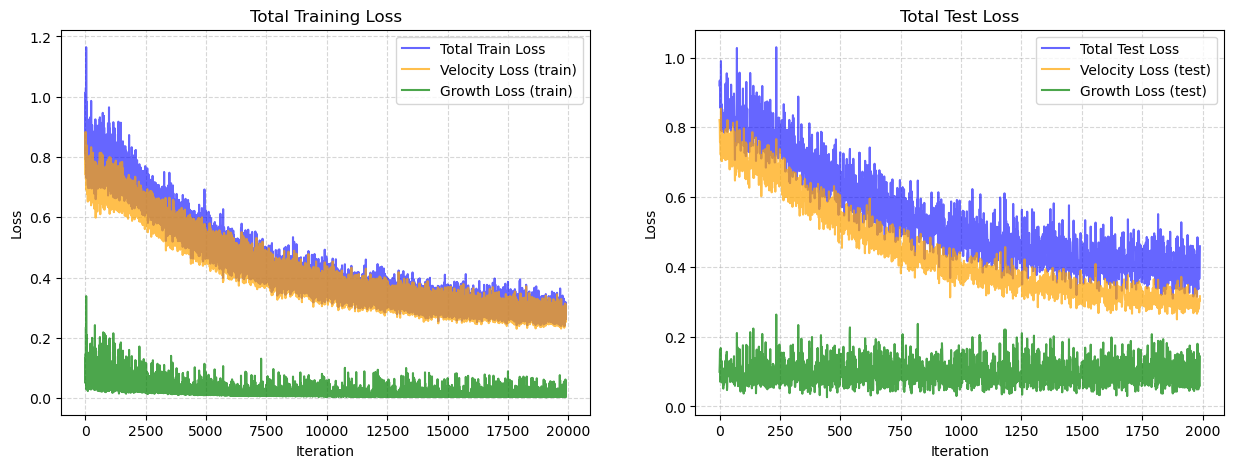

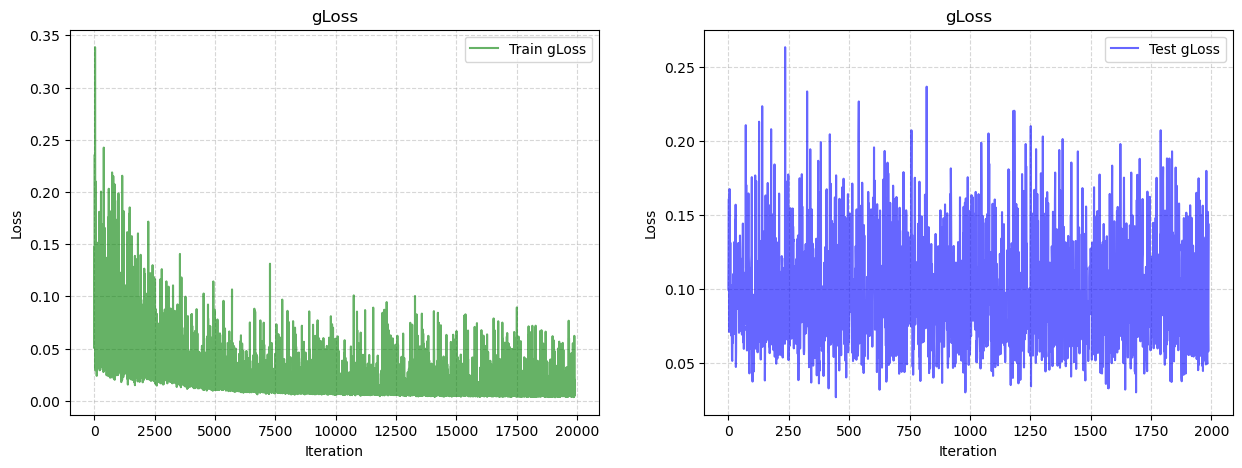

In [8]:
from src.evaluate import draw_loss
draw_loss(model_load_path,eval_interval = 10,cut = 100,save_path = results_save_path) # cut代表去掉前多少个epoch 避免前期loss过大影响观察

## inference & evalutaion

In [9]:
from src.evaluate.downstream import *
from src.evaluate.util import run_inference_and_reconstruct,evaluate_generated_results
from src.evaluate.evals_new import build_baseline_results

In [10]:
rulebook = adata_test.uns.get('global_rulebook')
if rulebook is None:
    raise ValueError("未找到 global_rulebook，请先确认数据经过了最新版 prepare_covariates 的处理！")

schema = rulebook["condition_tuple_schema"] 

# 我们直接从 adata_test 中，根据 schema 提取所有出现过的独立条件组合
# 然后直接转化为字典列表，这就是完美的 wishlist！
unique_conditions_df = adata_test.obs[schema].drop_duplicates()
wishlist = unique_conditions_df.to_dict(orient='records')

print(f"成功从测试集中提取了 {len(wishlist)} 个评估愿望 (Wishlist)！")
print(f"示例: {wishlist[0]}") 

# base_condition_key 通常是 schema 的第一个元素（如 'perturbation'）
base_condition_key = schema[0] 

# rulebook = adata_train.uns.get('global_rulebook')
# schema = rulebook["condition_tuple_schema"] 
# unique_conditions_df = adata_train.obs[schema].drop_duplicates()
# wishlist = unique_conditions_df.to_dict(orient='records')
# print(f"成功从测试集中提取了 {len(wishlist)} 个评估愿望 (Wishlist)！")
# print(f"示例: {wishlist[0]}") 
# base_condition_key = schema[0] 

成功从测试集中提取了 144 个评估愿望 (Wishlist)！
示例: {'cytokine': '4-1BBL', 'donor': 'Donor12'}


In [ ]:
# wishlist = [{'cytokine': '4-1BBL', 'donor': 'Donor12'}] 
#wishlist = [{'cytokine': 'CD30L', 'donor': 'Donor7'}]

In [ ]:
# 第一步：只管推断和生成
results_embedding, results_genes, sampled_indices = run_inference_and_reconstruct(
    model=model,
    adata_control=adata_control,
    adata_test=adata_test,
    wishlist=wishlist,
    condition_keys=condition_keys,
    condition_rep_keys=condition_rep_keys,
    sample_rep=sample_rep,
    device="cuda",
    n_particles = 20000,
    random_seed = 42,
    n_steps = 100,
)

inference_results = {"results_embedding":results_embedding,"results_genes":results_genes,"sampled_indices": sampled_indices}
with open(f"{results_save_path}/inference_results.pkl", "wb") as f:
    pickle.dump(inference_results, f)
    print(f"save inference_results to {results_save_path}/inference_results.pkl")

In [ ]:
if True:
    with open(f"{results_save_path}/inference_results.pkl", "rb") as f:
        inference_results = pickle.load(f)
        print(f"load inference_results")
    results_embedding = inference_results["results_embedding"]
    results_genes = inference_results["results_genes"]
    sampled_indices = inference_results["sampled_indices"]

In [ ]:
final_df, eval_artifacts = evaluate_generated_results(
    results_embedding=results_embedding,
    results_genes=results_genes,
    adata_control=adata_control,
    adata_test=adata_test,
    condition_combined_keys=condition_combined_keys,
    control_key=control_key,
    sample_rep=sample_rep,
    results_save_path=results_save_path,
    mass_deduct_keys=mass_deduct_keys,
    random_seed = 42,
    Edistance_sample_num = 10000,
    dist_max_cells= 10000,
    dist_top_n_degs = 50,
    deg_padj_cutoff = 0.01,
    deg_fc_cutoff = 1.0,
    deg_top_n_for_eval = 50,
    save_each = True,
    save_final = True,
    final_filename= "final_metrics.csv",
    use_groupwise_control = True,
    cell_type_key = "cell_type",
    detailed_perturbation = False,
    detailed_celltype = False,
)


In [ ]:
print(final_df)

## build baseline

In [11]:
results_genes, results_embedding = build_baseline_results(
    baseline_type="identity",
    adata_control=adata_control,
    adata_treated=adata_test,
    adata_train=adata_train,
    pert_key=condition_combined_keys,
    donor_key="donor",
    cytokine_key=condition_keys,
    embedding_key=sample_rep,
    rulebook=rulebook,
    use_groupwise_control=True,
)

with open(f"{results_save_path}/identity_results_embedding.pkl", "wb") as f:
    pickle.dump(results_embedding, f)
    print(f"save inference_results to {results_save_path}/identity_results_embedding.pkl")

with open(f"{results_save_path}/identity_results_genes.pkl", "wb") as f:
    pickle.dump(results_genes, f)
    print(f"save inference_results to {results_save_path}/identity_results_genes.pkl")


Building baseline 'identity' for 144 perturbations...
Done. Built 144 gene baselines and 144 latent baselines.
save inference_results to results/exp_20260404_155511_PBMC_small_hvg2000_gemini_test1_42_cellflow_0_True_X_pca_100_None_delta8_regm2/identity_results_embedding.pkl
save inference_results to results/exp_20260404_155511_PBMC_small_hvg2000_gemini_test1_42_cellflow_0_True_X_pca_100_None_delta8_regm2/identity_results_genes.pkl


In [ ]:
results_genes, results_embedding = build_baseline_results(
    baseline_type="mean_test_donor_response_across_cytokines",
    adata_control=adata_control,
    adata_treated=adata_test,
    adata_train=adata_train,
    pert_key=condition_combined_keys,
    donor_key="donor",
    cytokine_key=condition_keys,
    embedding_key=sample_rep,
    rulebook=rulebook,
    use_groupwise_control=True,
    min_reference_groups=1,
    fallback_to_identity=True,
)

with open(f"{results_save_path}/donor_mean_results_embedding.pkl", "wb") as f:
    pickle.dump(results_embedding, f)
    print(f"save inference_results to {results_save_path}/donor_mean_results_embedding.pkl")

with open(f"{results_save_path}/donor_mean_results_genes.pkl", "wb") as f:
    pickle.dump(results_genes, f)
    print(f"save inference_results to {results_save_path}/donor_mean_results_genes.pkl")

Precomputing all train/control group means...


In [ ]:
results_genes, results_embedding = build_baseline_results(
    baseline_type="mean_test_cytokine_response_across_donors",
    adata_control=adata_control,
    adata_treated=adata_test,
    adata_train=adata_train,
    pert_key=condition_combined_keys,
    donor_key="donor",
    cytokine_key=condition_keys,
    embedding_key=sample_rep,
    rulebook=rulebook,
    use_groupwise_control=True,
    min_reference_groups=1,
    fallback_to_identity=True,
)

with open(f"{results_save_path}/cyto_mean_results_embedding.pkl", "wb") as f:
    pickle.dump(results_embedding, f)
    print(f"save inference_results to {results_save_path}/cyto_mean_results_embedding.pkl")

with open(f"{results_save_path}/cyto_mean_results_genes.pkl", "wb") as f:
    pickle.dump(results_genes, f)
    print(f"save inference_results to {results_save_path}/cyto_mean_results_genes.pkl")

#### evaluate metrics

In [ ]:
if True:
    with open(f"{results_save_path}/identity_results_embedding.pkl", "rb") as f:
        results_embedding = pickle.load(f)
    with open(f"{results_save_path}/identity_results_genes.pkl", "rb") as f:
        results_genes = pickle.load(f)

In [ ]:
identity_final_df, eval_artifacts = evaluate_generated_results(
    results_embedding=results_embedding,
    results_genes=results_genes,
    adata_control=adata_control,
    adata_test=adata_test,
    condition_combined_keys=condition_combined_keys,
    control_key=control_key,
    sample_rep=sample_rep,
    results_save_path=results_save_path,
    mass_deduct_keys=mass_deduct_keys,
    random_seed = 42,
    Edistance_sample_num = 10000,
    dist_max_cells= 10000,
    dist_top_n_degs = 50,
    deg_padj_cutoff = 0.01,
    deg_fc_cutoff = 1.0,
    deg_top_n_for_eval = 50,
    save_each = False,
    save_final = True,
    final_filename= "final_metrics_baseline_identity.csv",
    use_groupwise_control = True,
    cell_type_key = "cell_type",
    detailed_perturbation = False,
    detailed_celltype = False,
)

In [ ]:
if True:
    with open(f"{results_save_path}/donor_mean_results_embedding.pkl", "rb") as f:
        results_embedding = pickle.load(f)
    with open(f"{results_save_path}/donor_mean_results_genes.pkl", "rb") as f:
        results_genes = pickle.load(f)

In [ ]:
donor_mean_final_df, eval_artifacts = evaluate_generated_results(
    results_embedding=results_embedding,
    results_genes=results_genes,
    adata_control=adata_control,
    adata_test=adata_test,
    condition_combined_keys=condition_combined_keys,
    control_key=control_key,
    sample_rep=sample_rep,
    results_save_path=results_save_path,
    mass_deduct_keys=mass_deduct_keys,
    random_seed = 42,
    Edistance_sample_num = 10000,
    dist_max_cells= 10000,
    dist_top_n_degs = 50,
    deg_padj_cutoff = 0.01,
    deg_fc_cutoff = 1.0,
    deg_top_n_for_eval = 50,
    save_each = False,
    save_final = True,
    final_filename= "final_metrics_baseline_donor_mean.csv",
    use_groupwise_control = True,
    cell_type_key = "cell_type",
    detailed_perturbation = False,
    detailed_celltype = False,
)

In [ ]:
if True:
    with open(f"{results_save_path}/cyto_mean_results_embedding.pkl", "rb") as f:
        results_embedding = pickle.load(f)
    with open(f"{results_save_path}/cyto_mean_results_genes.pkl", "rb") as f:
        results_genes = pickle.load(f)

In [ ]:
cyto_mean_final_df, eval_artifacts = evaluate_generated_results(
    results_embedding=results_embedding,
    results_genes=results_genes,
    adata_control=adata_control,
    adata_test=adata_test,
    condition_combined_keys=condition_combined_keys,
    control_key=control_key,
    sample_rep=sample_rep,
    results_save_path=results_save_path,
    mass_deduct_keys=mass_deduct_keys,
    random_seed = 42,
    Edistance_sample_num = 10000,
    dist_max_cells= 10000,
    dist_top_n_degs = 50,
    deg_padj_cutoff = 0.01,
    deg_fc_cutoff = 1.0,
    deg_top_n_for_eval = 50,
    save_each = False,
    save_final = True,
    final_filename= "final_metrics_baseline_cyto_mean.csv",
    use_groupwise_control = True,
    cell_type_key = "cell_type",
    detailed_perturbation = False,
    detailed_celltype = False,
)

### more downstream

In [ ]:
# 1. 检查漂移
counts, fractions = check_population_shift(
    adata_test,
    adata_control,
    condition_combined_key="condition_combined", # 你在 prepare_covariates 阶段生成的列
    cell_type_key="cell_type",
    control_tuple_name="('PBS', 'control')" 
)

# 2. 提取指标与 Tuple 拆解
# 假设你的 rulebook 保存在 adata_treated.uns['global_rulebook']
rulebook = adata_test.uns.get('global_rulebook')

df_metrics = extract_v_and_g_metrics(
    inference_results=results_embedding,
    adata_source=adata_control[indices],
    rulebook=rulebook,
    sample_rep = sample_rep,
    cell_type_key="cell_type",
    n_neighbors=15,
    knn_weights="distance",
    use_groupwise_control=True
)

# 3. 循环绘图 (遍历所有预测的 Tuple 身份)
key_cell_types = [
    "CD14 Mono", "CD4 Memory", "CD4 Naive", "B Naive", "CD8 Memory", 
    "CD8 Naive", "NK", "B Intermediate/Memory", "CD16 Mono", "NKT", 
    "MAIT", "NK CD56bright", "Treg", "HSPC", "cDC", "ILC", "Plasmablast", "pDC"
]

all_predicted_tuples = list(results_embedding.keys())



for tuple_str in all_predicted_tuples:
    plot_predicted_mass_by_celltype(df_metrics, tuple_str, key_cell_types)
    plot_predicted_mass_with_true_label(
        df_metrics=df_metrics, 
        target_tuple_str=tuple_str, 
        target_cell_types=key_cell_types, 
        adata_control=adata_control,
        adata_full=adata_test,
        rulebook=rulebook,
        use_groupwise_control=True,
        condition_combined_key = condition_combined_keys,
        cell_type_key= "cell_type",
        mass_deduct_keys=mass_deduct_keys,
    )


In [ ]:
from src.evaluate import evaluate_all
from src.evaluate.downstream import *

rulebook = adata_train.uns.get('global_rulebook')
if rulebook is None:
    raise ValueError("未找到 global_rulebook，请先确认数据经过了最新版 prepare_covariates 的处理！")

schema = rulebook["condition_tuple_schema"] 


unique_conditions_df = adata_train.obs[schema].drop_duplicates()
wishlist = unique_conditions_df.to_dict(orient='records')

print(f"成功从train中提取了 {len(wishlist)} 个评估愿望 (Wishlist)！")
print(f"示例: {wishlist[0]}") 

# base_condition_key 通常是 schema 的第一个元素（如 'perturbation'）
base_condition_key = schema[0] 


final_df, artifacts = evaluate_all(
    model=model,
    adata_control=adata_control,
    adata_test=adata_train,
    
    wishlist=wishlist,                               # 传入生成的愿望字典列表
    condition_keys=base_condition_key,               # 基础扰动名 (供抽取 Embedding)
    condition_combined_keys=condition_combined_keys,       # 传给下游评估函数作为 pert_key 匹配

    
    control_key=control_key,
    condition_rep_keys=condition_rep_keys,
    sample_rep=sample_rep,
    device=device,
    mass_deduct_keys = mass_deduct_keys,
    n_particles=50000,
    random_seed=42,
    n_steps=50,
    Edistance_sample_num=20000,
    dist_max_cells=20000,
    dist_n_bins=200,
    dist_top_n_degs=50,
    results_save_path=results_save_path,
    scvi_model_load_path=scvi_model_load_path,
    state_model_load_path=state_model_load_path,
    save_each=False,
    save_final=True,
    final_filename=f"final_metrics1_train.csv",
    detailed=True,
    use_groupwise_control=  True,
)

print(final_df)

with open(f"{results_save_path}_train", "wb") as f:
    pickle.dump(artifacts, f)

成功从train中提取了 864 个评估愿望 (Wishlist)！
示例: {'cytokine': '4-1BBL', 'donor': 'Donor1'}
准备为 864 个条件进行推理...


  2%|▏         | 18/864 [00:47<34:19,  2.43s/it] 

In [ ]:
indices = artifacts["indices"]
results_embedding = artifacts["results_embedding"]
results_genes = artifacts["results_genes"]


In [ ]:
# 1. 检查漂移
counts, fractions = check_population_shift(
    adata_train,
    adata_control,
    condition_combined_key="condition_combined", # 你在 prepare_covariates 阶段生成的列
    cell_type_key="cell_type",
    control_tuple_name="('PBS', 'control')" 
)

# 2. 提取指标与 Tuple 拆解
# 假设你的 rulebook 保存在 adata_treated.uns['global_rulebook']
rulebook = adata_train.uns.get('global_rulebook')

df_metrics = extract_v_and_g_metrics(
    inference_results=results_embedding,
    adata_source=adata_control[indices],
    rulebook=rulebook,
    sample_rep = sample_rep,
    cell_type_key="cell_type",
    n_neighbors=15,
    knn_weights="distance",
    use_groupwise_control=True
)

# 3. 循环绘图 (遍历所有预测的 Tuple 身份)
key_cell_types = [
    "CD14 Mono", "CD4 Memory", "CD4 Naive", "B Naive", "CD8 Memory", 
    "CD8 Naive", "NK", "B Intermediate/Memory", "CD16 Mono", "NKT", 
    "MAIT", "NK CD56bright", "Treg", "HSPC", "cDC", "ILC", "Plasmablast", "pDC"
]

all_predicted_tuples = list(results_embedding.keys())



for tuple_str in all_predicted_tuples:
    plot_predicted_mass_by_celltype(df_metrics, tuple_str, key_cell_types)
    plot_predicted_mass_with_true_label(
        df_metrics=df_metrics, 
        target_tuple_str=tuple_str, 
        target_cell_types=key_cell_types, 
        adata_control=adata_control,
        adata_full=adata_train,
        rulebook=rulebook,
        use_groupwise_control=True,
        condition_combined_key = condition_combined_keys,
        cell_type_key= "cell_type",
        mass_deduct_keys=mass_deduct_keys,
    )


In [ ]:
with open(f"{results_save_path}_test", "wb") as f:
    artifacts = pickle.load(f)

In [ ]:
indices = artifacts["indices"]
results_embedding = artifacts["results_embedding"]
results_genes = artifacts["results_genes"]
adata_source = adata_control[indices]

In [ ]:
print(adata_test.obs["cell_type"].value_counts().to_string())

In [ ]:
sc.tl.pca(adata_control, svd_solver='arpack')
sc.pp.neighbors(adata_control, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata_control)

In [ ]:
sc.pl.umap(
    adata_control, 
    color='cell_type',      # 按细胞类型着色
    frameon=False,          # 【关键】去掉周围的黑框和坐标轴
    title='',               # 去掉标题（方便后期AI排版）
    legend_fontsize=10,     # 标签字体大小
    size=10,                # 调整点的大小
    save='celltype.pdf'    # 保存为矢量图
)
sc.pl.umap(
    adata_control, 
    vmin=0,
    vmax=6,
    color=[f'FCN1', f'IDO1'], 
)

In [ ]:
adata_true = adata_test[adata_test.obs["cytokine"]=="IL-15"].copy()
adata_pred = results_genes["IL-15"]

In [ ]:
sc.tl.ingest(adata_true, adata_control, embedding_method='umap')
sc.tl.ingest(adata_pred, adata_control, embedding_method='umap')

In [ ]:
adata_control.obs['dataset'] = 'Control'
adata_true.obs['dataset'] = 'True'
adata_pred.obs['dataset'] = 'Pred'

In [ ]:
adata_all = adata_control.concatenate(adata_true, batch_key='dataset',batch_categories=["Control", "True"])

adata_all.obs['plot_color'] = adata_all.obs['dataset'].astype(str)
color_map = {'Control': 'black', 'True': '#1f77b4'} # 也可以用 hex 颜色码

# sc.pl.umap(
#     adata_all, 
#     color='plot_color', 
#     groups=['Control'], # 只高亮 Control
#     palette=color_map,
#     frameon=False,
#     title='Control',
#     size=10 # 根据细胞数调整点大小
# )

sc.pl.umap(
    adata_all, 
    color='plot_color', 
    groups=['True'],    # 只高亮 Test
    palette=color_map,
    frameon=False,
    title='Test Data (Projected)',
    size=10
)
import numpy as np

# 1. 复制一个用于绘图的对象，以免修改原数据
adata_plot = adata_all.copy()

# 2. 将 'Control' 组的这两个基因的表达量设为 NaN (空值)
# 这样 Scanpy 就会把它们识别为缺失值，并涂上 na_color
mask_control = adata_plot.obs['dataset'] == 'Control'

# 注意：如果 .X 是稀疏矩阵，操作稍微麻烦点；如果是 dense 矩阵或已放到 .obs 里可以直接操作
# 这里演示最通用的方法：先把基因值存入 obs，再手动修改
for gene in ['FCN1', 'IDO1']:
    # 获取表达量 (处理稀疏矩阵的情况)
    if hasattr(adata_plot.X, "toarray"):
        values = adata_plot[:, gene].X.toarray().flatten()
    else:
        values = adata_plot[:, gene].X.flatten()
    
    # 存入 obs
    adata_plot.obs[f'plot_{gene}'] = values
    
    # 将 Control 组的值设为 NaN
    adata_plot.obs.loc[mask_control, f'plot_{gene}'] = np.nan

# 3. 绘图
sc.pl.umap(
    adata_plot, 
    color=[f'plot_FCN1', f'plot_IDO1'], 
    na_color='lightgrey', # 这里设置背景色（Control的颜色）
    na_in_legend=False,   # 图例中不显示 NaN
    cmap='viridis',       # Pred 组的颜色映射
    frameon=False,
    vmin=0,
    vmax=6,
    size=10,
    title=['FCN1 (True Only)', 'IDO1 (True Only)']
)


In [ ]:
adata_all = adata_control.concatenate(adata_pred, batch_key='dataset',batch_categories=["Control", "Pred"])

adata_all.obs['plot_color'] = adata_all.obs['dataset'].astype(str)
color_map = {'Control': 'black', 'Pred': '#1f77b4'} # 也可以用 hex 颜色码

sc.pl.umap(
    adata_all, 
    color='plot_color', 
    groups=['Pred'],    # 只高亮 Test
    palette=color_map,
    frameon=False,
    title='Pred Data (Projected)',
    size=10
)


import numpy as np

# 1. 复制一个用于绘图的对象，以免修改原数据
adata_plot = adata_all.copy()

# 2. 将 'Control' 组的这两个基因的表达量设为 NaN (空值)
# 这样 Scanpy 就会把它们识别为缺失值，并涂上 na_color
mask_control = adata_plot.obs['dataset'] == 'Control'

# 注意：如果 .X 是稀疏矩阵，操作稍微麻烦点；如果是 dense 矩阵或已放到 .obs 里可以直接操作
# 这里演示最通用的方法：先把基因值存入 obs，再手动修改
for gene in ['FCN1', 'IDO1']:
    # 获取表达量 (处理稀疏矩阵的情况)
    if hasattr(adata_plot.X, "toarray"):
        values = adata_plot[:, gene].X.toarray().flatten()
    else:
        values = adata_plot[:, gene].X.flatten()
    
    # 存入 obs
    adata_plot.obs[f'plot_{gene}'] = values
    
    # 将 Control 组的值设为 NaN
    adata_plot.obs.loc[mask_control, f'plot_{gene}'] = np.nan

# 3. 绘图
sc.pl.umap(
    adata_plot, 
    color=[f'plot_FCN1', f'plot_IDO1'], 
    na_color='lightgrey', # 这里设置背景色（Control的颜色）
    na_in_legend=False,   # 图例中不显示 NaN
    cmap='viridis',       # Pred 组的颜色映射
    frameon=False,
    vmin=0,
    vmax=6,
    size=10,
    title=['FCN1 (Pred Only)', 'IDO1 (Pred Only)']
)
import numpy as np

# 1. 复制一份用于绘图，避免污染原数据
adata_plot = adata_all.copy()

# 2. 初始化一个新的列用于绘图，先全部设为 NaN (灰色)
adata_plot.obs['plot_mass'] = np.nan

# 3. 找到 Pred 组的位置
mask_pred = adata_plot.obs['dataset'] == 'Pred'

# 4. 将 mass 的值填入 Pred 组对应的位置
# .values 确保赋值时忽略索引名称差异（concat 可能会改索引名）
adata_plot.obs.loc[mask_pred, 'plot_mass'] = adata_pred.obs['mass'].values

# 5. 绘图
sc.pl.umap(
    adata_plot, 
    color='plot_mass', 
    na_color='lightgrey', # Control 组（NaN）显示的颜色
    na_in_legend=False,   # 图例中不显示灰色
    cmap='viridis',       # mass 的色阶
    frameon=False,
    size=10,
    title='Mass on Projected Data'
)

In [ ]:
adata_pred

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def diagnose_mass_prediction(pred_adata, gene_name='CDCA2'):
    mass = pred_adata.obs['mass'].values
    expr = pred_adata[:, gene_name].X.flatten() # 或者是 .layers['counts'] 等
    
    # 1. 打印统计数据
    print(f"=== Mass Statistics for {gene_name} prediction ===")
    print(f"Mean Mass: {np.mean(mass):.4f}")
    print(f"Max  Mass: {np.max(mass):.4f}")
    print(f"Min  Mass: {np.min(mass):.4f}")
    print(f"Std  Mass: {np.std(mass):.4f}")
    
    # 2. 绘图：Mass vs Target Gene Expression
    plt.figure(figsize=(10, 4))
    
    # 子图1: Mass 的直方图
    plt.subplot(1, 2, 1)
    plt.hist(mass, bins=50, color='green', alpha=0.7)
    plt.title("Distribution of Predicted Mass")
    plt.xlabel("Mass")
    plt.ylabel("Count")
    
    # 子图2: Mass vs Expression
    plt.subplot(1, 2, 2)
    plt.scatter(expr, mass, alpha=0.5, s=10, c=mass, cmap='viridis')
    plt.title(f"Mass vs {gene_name} Expression")
    plt.xlabel(f"{gene_name} Expression")
    plt.ylabel("Predicted Mass")
    plt.colorbar(label='Mass')
    
    plt.tight_layout()
    plt.show()

# 运行诊断
for gene in target_genes:
    diagnose_mass_prediction(results_genes[gene], gene)